# Example of PRD equilibrium in SPARC using TokaMaker

In [1]:
import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.interpolate import CubicSpline
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

## Load TokaMaker library

To load the TokaMaker python module we need to tell python where to the module is located. This can be done either through the `PYTHONPATH` environment variable or using within a script using `sys.path.append()` as below, where we look for the environement variable `OFT_ROOTPATH` to provide the path to where the OpenFUSIONToolkit is installed (`/Applications/OFT` on macOS).

In [2]:
tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.util import mu0
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import read_eqdsk

## Setup solver

### Initialize TokaMaker object
First we create a TokaMaker instance to use for equilibrium calculations. Note at present only a single instance can be used per python kernel, so this command should only be called **once** in a given Jupyter notebook or python script. In the future this restriction may be relaxed.

In [3]:
myOFT = OFT_env(nthreads=6)
mygs = TokaMaker(myOFT)

         If correct, this may significantly degrade performance due to oversubcription
#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    main
Revision id:           51e08bd
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    6
Fortran input file    = /var/folders/9p/90ydvncx0zb8sqr976fmrfxr0000gn/T/oft_46875/oftpyin
XML input file        = none
Integer Precisions    =    4   8
Float Precisions      =    4   8  16
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------



### Load mesh into TokaMaker
Now we load the mesh generated in the meshing notebook using `load_gs_mesh()` and `mygs.setup_mesh()`. Then we use `mygs.setup_regions()` to define the different region types. Finally, we call `mygs.setup()` to setup the required solver objects. During this call we can specify the desired element order (min=2, max=4) and the toroidal field through $F_0 = B_0*R_0$, where $B_0$ is the toroidal field at a reference location $R_0$.

For SPARC we also set `mygs.lim_zmax`, which excludes points on the limiter where `abs(z) > lim_zmax` (inside the divertor) from being erronerously recognized as limiter points. This isn't strictly necessary for this example, but when possible excluding geometry from limiter consideration is always helpful. We also increase the maximum number of Picard iterations in the equilibrium solve to 80 from the default of 40.

In [4]:
mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = load_gs_mesh('SPARC_mesh-240613.h5')
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.lim_zmax = 1.15
mygs.settings.maxits = 80
mygs.setup(order=2, F0=12.15655*1.85)


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  2.898E+01
    # of points  =    5189
    # of edges   =   15422
    # of cells   =   10234
    # of boundary points =     142
    # of boundary edges  =     142
    # of boundary cells  =     142
  Resolution statistics:
    hmin =  1.258E-03
    hrms =  8.616E-02
    hmax =  2.199E-01
  Surface grounded at vertex    1304


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    1.1550000000000000E-003


### Define a vertical stability coil
Like many elongated equilibria, the equilibrium we seek to compute below is vertically unstable. So we define a pair of coils, and corresponding polarities, that will be used to control the vertical position in the equilibrium solve. In this case we use the actual SPARC Vertical Stability Coil (VSC).

**Note:** This is not required for the inverse solve below, but can be useful for forward solves, where coil currents are otherwise fixed.

In [5]:
# vsc_signs = np.zeros((mygs.ncoils,), dtype=np.float64)
# vsc_signs[mygs.coil_sets['VSC']['id']] = 1.0
# print(vsc_signs)
# mygs.set_coil_vsc(vsc_signs)

mygs.set_coil_vsc({'VSC': 1.0})

### Define hard limits on coil currents
Hard limits on coil currents can be set using `mygs.set_coil_bounds()`, which are then used in the inverse solve below.

Note that the size of the bounds array is `(ncoils+1,2)` as bounds can also be set for the virtual VSC set, which is treated as a separate degree of freedom if defined.

In [6]:
# coil_bounds = np.zeros((mygs.ncoils+1,2), dtype=np.float64)
# for name, coil in mygs.coil_sets.items():
#     if name.startswith('CS'):
#         bounds = [-4.20E+04,4.20E+04]
#     elif name.startswith('PF1') or name.startswith('PF2'):
#         bounds = [-1.50E+04,4.20E+04]
#     elif name.startswith('PF3'):
#         bounds = [-4.20E+04,2.00E+04]
#     elif name.startswith('PF4'):
#         bounds = [-4.20E+04,0.0]
#     elif name.startswith('DV'):
#         bounds = [-3.20E+04,3.20E+04]
#     elif name.startswith('VS'):
#         bounds = [-3.00E+04,3.00E+04]
#         coil_bounds[-1,:] = bounds
#     coil_bounds[coil['id'],:] = np.array(bounds)
# coil_bounds[-1,:] = coil_bounds[mygs.coil_sets['VSC']['id'],:]
coil_bounds = {}
for key in mygs.coil_sets:
    if key.startswith('CS'):
        coil_bounds[key] = [-4.20E+04,4.20E+04]
    elif key.startswith('PF1') or key.startswith('PF2'):
        coil_bounds[key] = [-1.50E+04,4.20E+04]
    elif key.startswith('PF3'):
        coil_bounds[key] = [-4.20E+04,2.00E+04]
    elif key.startswith('PF4'):
        coil_bounds[key] = [-4.20E+04,0.0]
    elif key.startswith('DV'):
        coil_bounds[key] = [-3.20E+04,3.20E+04]
    elif key.startswith('VS'):
        coil_bounds[key] = [-3.00E+04,3.00E+04]
        coil_bounds['VSC'] = coil_bounds[key]

mygs.set_coil_bounds(coil_bounds)

## Replicate PRD equilibrium
We now seek to replicate the PRD equilibrium from the SPARC public repo (`SPARC_DN_PRD_freegs_513_20221206.eqdsk`).

In [18]:
PRD_EQ = read_eqdsk('SPARC_DN_PRD_freegs_513_20221206.eqdsk')

# # Plot EQDSK LCFS
# R = np.linspace(PRD_EQ['rleft'],PRD_EQ['rleft']+PRD_EQ['rdim'],PRD_EQ['nr'])
# Z = np.linspace(PRD_EQ['zmid']-PRD_EQ['zdim']/2.0,PRD_EQ['zmid']+PRD_EQ['zdim']/2.0,PRD_EQ['nz'])
# fig, ax = plt.subplots(1,1)
# mygs.plot_machine(fig,ax)
# _ = ax.contour(R,Z,PRD_EQ['psirz'],levels=[PRD_EQ['psibry'],])

### Define global quantities and targets
For the inverse case we usually define a target for the total plasma current. The plasma pressure/beta can be constrained in several different ways, but in this case we specify the on-axis pressure from the PRD gEQDSK file.

**Note:** These constraints can be considered "hard" constraints, where they will be matched to good tolerance as long as the calculation converges.

**Note:** The plasma current must always positive in TokaMaker, to create equilibria with opposing current and field directions change the sign of $F_0$ above.

In [8]:
Ip_target = abs(PRD_EQ['ip'])
pax_target = PRD_EQ['pres'][0]
mygs.set_targets(Ip=Ip_target,pax=pax_target)
print(f'Ip_target = {Ip_target:.2f} A, pax_target = {pax_target:.2e} Pa')

Ip_target = 8700000.00 A, pax_target = 2.60e+06 Pa


### Define shape targets
In order to constrain the shape of the plasma we can utilize two types of constraints:
 1. `isoflux` points, which are points we want to lie on the same flux surface (eg. the LCFS)
 2. `saddle` points, where we want the poloidal magnetic field to vanish (eg. X-points). While one can also use this constraint to enforce a magnetic axis location, instead `set_targets` should be used with arguments `R0` and `V0`.

**Note:** These constraints can be considered "soft" constraints, where the calculation attempts to minimize error in satisfying these constraints subject to other constraints and regularization.

Here we define isoflux points from the LCFS in the gEQDSK file, which we also mirror across the midplane to ensure the up-down symmetry that is desired in this case but not quite achieved in the input file.

In [9]:
x_ind = abs(PRD_EQ['rzout'][:,1]).argmax()
isoflux_pts = PRD_EQ['rzout'][::40,:]
isoflux_pts = np.vstack((isoflux_pts,[PRD_EQ['rzout'][x_ind,:],]))
isoflux_pts_mirror = isoflux_pts.copy()
isoflux_pts_mirror[:,1] *= -1.0
isoflux_pts = np.vstack((isoflux_pts,isoflux_pts_mirror))
mygs.set_isoflux(isoflux_pts)

### Define coil regularization matrix
In general, for a given coil set a given plasma shape cannot be exactly reproduced, which generally yields large amplitude coil currents if no constraint on the coil currents is applied. As a result, it is useful to include regularization terms for the coils to balance minimization of the shape error with the amplitude of current in the free coils. In TokaMaker these regularization terms have the general form of a vector of targets (often zero), a regularization matrix that maps the coil currents to the targets, and a vector of weights that can be used to control the relative impact of each term in the minimization.

Here we define two types of regularization targets:
 1. Targets that act to penalize up-down assymetry in U/L coil pairs
 2. Targets the act to penalize the amplitude of current in each coil

In the later case this regularization acts to penalize the amplitude of current in each coil, acting to balance coil current with error in the shape targets. Additionally, this target is also used to "disable" several coils by setting the weight on their targets high to strongly penalize non-zero current. Note that the VSC set is disabled to prevent up-down symmetric current in these coils. The actual up-down asymmetric current will be provided by the dedicated VSC virtual coil.

In [10]:
coil_regmat = np.zeros((mygs.ncoils+1,mygs.ncoils+1), dtype=np.float64)
coil_reg_weights = np.zeros((mygs.ncoils+1,), dtype=np.float64)
coil_targets = np.zeros((mygs.ncoils+1,), dtype=np.float64)
disable_list = ('DV1','DV2')
for name, coil in mygs.coil_sets.items():
    if name.find('U') >= 0: # Set regularization to enforce up-down symmetry
        coil_regmat[coil['id'],coil['id']] = 1.0
        coil_regmat[coil['id'],mygs.coil_sets[name.replace('U','L')]['id']] = -1.0
        coil_reg_weights[coil['id']] = 1.E3
    else: # Normal regularization
        coil_regmat[coil['id'],coil['id']] = 1.0
        if name[:3] in disable_list:
            coil_reg_weights[coil['id']] = 1.E4
        else:
            coil_reg_weights[coil['id']] = 1.E-1

# Disable virtual VSC coil
coil_regmat[-1,-1] = 1.0
coil_reg_weights[-1] = 1.E4

mygs.set_coil_reg(coil_regmat,reg_weights=coil_reg_weights,reg_targets=coil_targets)

### Define flux functions
Here we match the $F*F'$, $P'$, and $q$ profiles to those in the reference file. To do this we will use the `linterp` profile type that defines profiles as piecewise linear functions. Additionally, we force the profiles to go to zero at the plasma boundary.

In [11]:
psi_eqdsk = np.linspace(0.0,1.0,PRD_EQ['nr'])
# Create new F*F' profile
ffp_prof = {'type': 'linterp', 'x': psi_eqdsk, 'y': np.interp(psi_eqdsk,psi_eqdsk,PRD_EQ['ffprim'])}
ffp_prof['y'] /= ffp_prof['y'][0] # Normalize profile (not required but convienient)
ffp_prof['y'][-1] = 0.0 # Set edge to zero
# Create new P' profile
pp_prof = {'type': 'linterp', 'x': psi_eqdsk, 'y': np.interp(psi_eqdsk,psi_eqdsk,PRD_EQ['pprime'])}
pp_prof['y'] /= pp_prof['y'][0] # Normalize profile (not required but convienient)
pp_prof['y'][-1] = 0.0 # Set edge to zero
# Update profiles in TokaMaker
mygs.set_profiles(ffp_prof=ffp_prof,pp_prof=pp_prof)

### Initialize equilibrium calculation
We are almost ready to compute a free-boundary equilibrium, but first we need to initialize the flux function $\psi$, which can be done using `mygs.init_psi()`. This subroutine initializes the flux using the specified `Ip_target` from above, which is evenly distributed over the entire plasma region or only with a boundary defined using a center point (R,Z), minor radius (a), and elongation and triangularity. Coil currents are also initialized at this point using the constraints above and this uniform plasma current initialization. 

We plot the solution and coil currents after initialization but _before_ the Grad-Shafranov solve for reference.

In [17]:
# mygs.init_psi(1.82,0.0,0.56,1.7,0.2)
# fig, ax = plt.subplots(1,1)
# mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]',coil_symmap=True)
# mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5)
# mygs.plot_constraints(fig, ax)
# Print initial coil currents
# print()
# print("Coil Currents [kA]:")
# coil_currents, _ = mygs.get_coil_currents()
# for key in mygs.coil_sets:
#     i = mygs.coil_sets[key]['id']
#     if coil_currents[i] >= 0.0:
#         proximity = coil_currents[i]*100/coil_bounds[i,1]
#         near_limit = coil_bounds[i,1]
#     else:
#         proximity = coil_currents[i]*100/coil_bounds[i,0]
#         near_limit = coil_bounds[i,0]
#     print('  {0:10} {1:10.2F} ({2:7.2F}) [{3:6.2F}%]'.format(key+":",coil_currents[i]/1.E3,near_limit/1.E3,proximity))

### Compute free-boundary equilibrium
`mygs.solve()` is then called to compute a self-consitent Grad-Shafranov equilibrium. If the result variable (`err_flag`) is zero then the solution has converged to the desired tolerance ($10^{-6}$ by default).

In [13]:
_ = mygs.solve()
psi0 = mygs.get_psi(normalized=False)
coil_currents, _ = mygs.get_coil_currents()

Starting non-linear GS solver
     1  1.5237E+01  4.1769E+00  1.0605E-01  1.9017E+00 -2.9921E-03  3.8828E-07
     2  2.8964E+01  3.0708E+00  6.0878E-02  1.8976E+00 -1.9798E-03  4.1967E-07
     3  3.4474E+01  2.7445E+00  3.9419E-01  1.8944E+00 -1.4055E-03  2.7480E-07
     4  3.6937E+01  2.6006E+00  1.8529E-01  1.8925E+00 -1.0453E-03  1.9688E-07
     5  3.8071E+01  2.5398E+00  8.8205E-02  1.8914E+00 -7.9634E-04  1.4896E-07
     6  3.8611E+01  2.5125E+00  3.6040E-02  1.8908E+00 -6.1260E-04  1.1538E-07
     7  3.8875E+01  2.4997E+00  1.4206E-02  1.8905E+00 -4.7139E-04  9.0234E-08
     8  3.9005E+01  2.4936E+00  6.6163E-03  1.8903E+00 -3.6013E-04  7.0729E-08
     9  3.9070E+01  2.4906E+00  3.0282E-03  1.8902E+00 -2.7123E-04  5.5267E-08
    10  3.9103E+01  2.4891E+00  1.3145E-03  1.8902E+00 -1.9963E-04  4.2867E-08
    11  3.9120E+01  2.4884E+00  6.2432E-04  1.8902E+00 -1.4172E-04  3.2861E-08
    12  3.9129E+01  2.4880E+00  4.7624E-04  1.8901E+00 -9.4792E-05  2.4762E-08
    13  3.9133E+01  2.

### Print equilibrium information and coil currents
Basic parameters can be displayed using the `mygs.print_info()` method. For access to these quantities as variables instead the `mygs.get_stats()` can be used.

The final coil currents can also be retrieved using the `mygs.get_coil_currents()` method, which are all within the approximate coil limits imposed above.

Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    8.7000E+06
  Current Centroid [m]    =    1.843  0.000
  Magnetic Axis [m]       =    1.890  0.000
  Elongation              =    1.961 (U:  1.976, L:  1.946)
  Triangularity           =    0.529 (U:  0.536, L:  0.523)
  Plasma Volume [m^3]     =   20.207
  q_0, q_95               =    0.935  3.150
  Plasma Pressure [Pa]    =   Axis:  2.5951E+06, Peak:  2.5951E+06
  Stored Energy [J]       =    1.7930E+07
  <Beta_pol> [%]          =   35.5058
  <Beta_tor> [%]          =    1.0056
  <Beta_n>   [%]          =    0.8014
  Diamagnetic flux [Wb]   =    2.3930E-01
  Toroidal flux [Wb]      =    2.3102E+01
  l_i                     =    1.2982


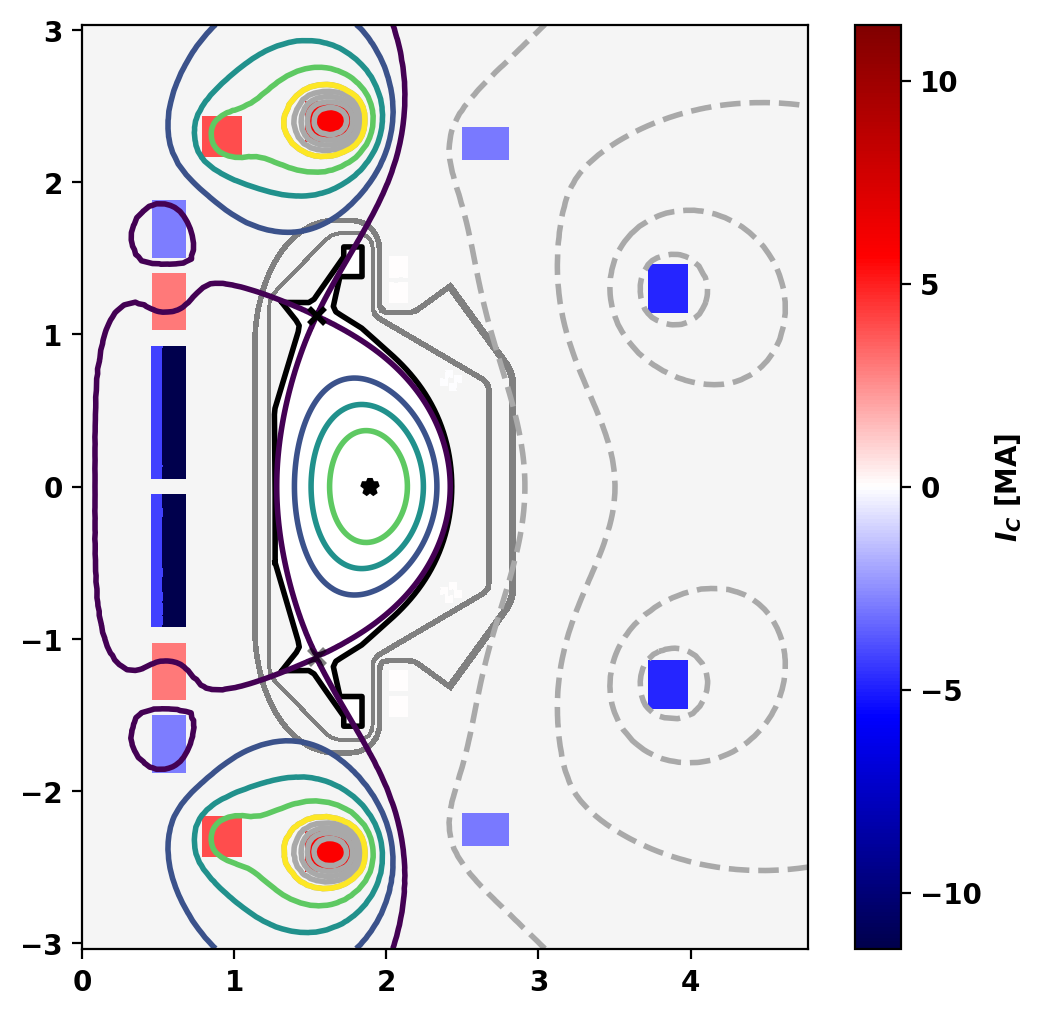

In [14]:
mygs.print_info()

# Plot first case surfaces
fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]',coil_symmap=True)
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5)

# Print final coil currents
# print()
# print("Coil Currents [kA]:")
# coil_currents, _ = mygs.get_coil_currents()
# for key in mygs.coil_sets:
#     i = mygs.coil_sets[key]['id']
#     if coil_currents[i] >= 0.0:
#         proximity = coil_currents[i]*100/coil_bounds[i,1]
#         near_limit = coil_bounds[i,1]
#     else:
#         proximity = coil_currents[i]*100/coil_bounds[i,0]
#         near_limit = coil_bounds[i,0]
#     print('  {0:10} {1:10.2F} ({2:7.2F}) [{3:6.2F}%]'.format(key+":",coil_currents[i]/1.E3,near_limit/1.E3,proximity))

### Compare updated profiles
We now use compare the updated results showing that all quantities are well matched across the entire plasma.

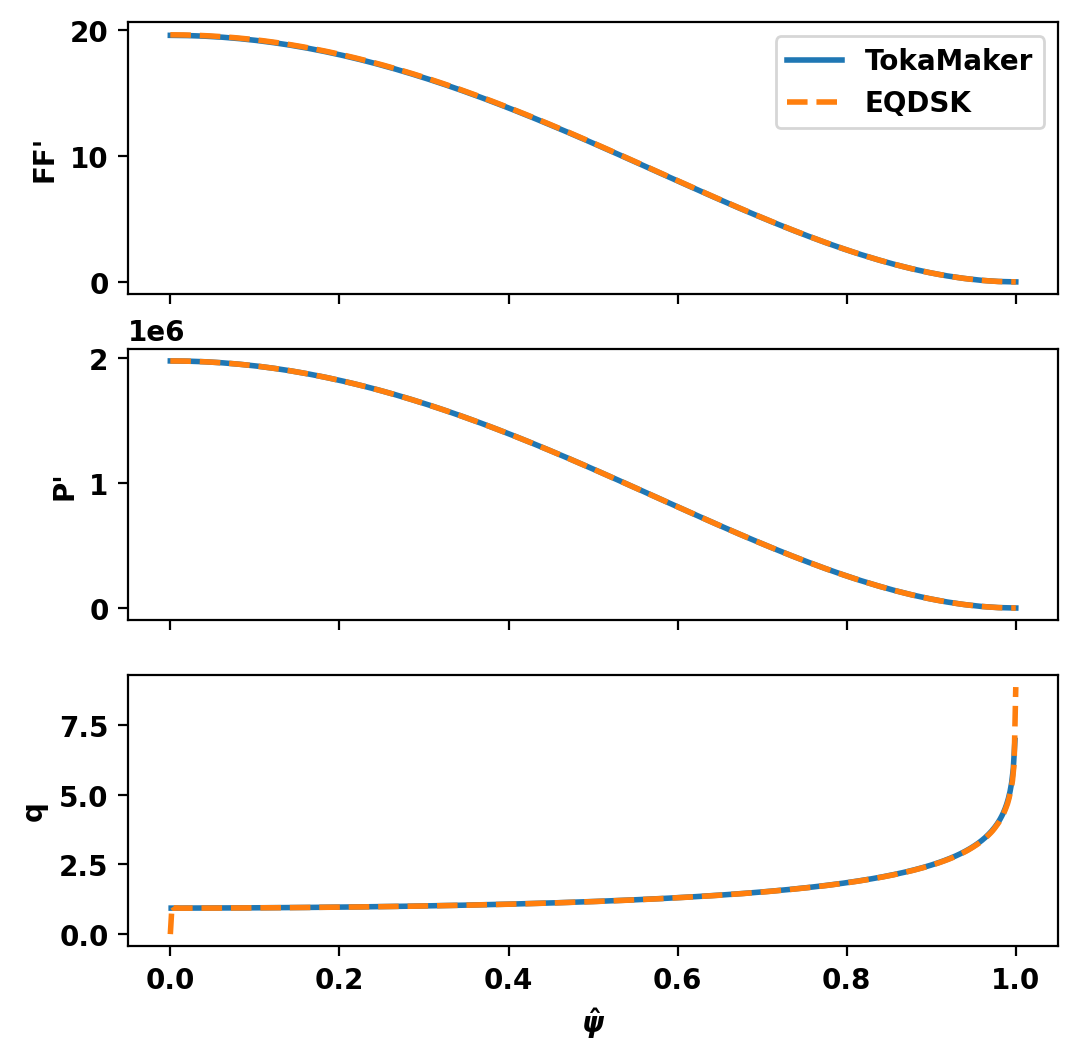

In [15]:
psi,f,fp,p,pp = mygs.get_profiles()
psi_q,qvals,ravgs,dl,rbounds,zbounds = mygs.get_q(psi_pad=0.001,npsi=PRD_EQ['nr'])

fig, ax = plt.subplots(3,1,sharex=True)

# Plot F*F'
ax[0].plot(psi,f*fp,label='TokaMaker')
ax[0].plot(psi_eqdsk,PRD_EQ['ffprim'],'--',label='EQDSK')
ax[0].set_ylabel("FF'")
ax[0].legend()

# Plot P'
ax[1].plot(psi,pp)
ax[1].plot(psi_eqdsk,PRD_EQ['pprime'],'--')
ax[1].set_ylabel("P'")

# Plot q
ax[2].plot(psi_q,qvals)
ax[2].plot(psi_eqdsk,PRD_EQ['qpsi'],'--')
ax[2].set_ylabel("q")
_ = ax[-1].set_xlabel(r"$\hat{\psi}$")

### Save equilibrium to gEQDSK format

In [16]:
# mygs.save_eqdsk('SPARC_DN_PRD_tMaker_513_20221206.eqdsk',lcfs_pad=0.005,run_info=PRD_EQ['case'].strip())